# Exercise - Car engine condition classification using LSTM

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## Load and preprocess data
Dataset: https://www.timeseriesclassification.com/description.php?Dataset=FordA

In [2]:
def load_ucr_txt(path):
    """
    Args:
        path: filepath of the .txt file to load.
    """
    data = np.loadtxt(path)

    y = data[:, 0]
    X = data[:, 1:]

    return X, y

In [3]:
# TODO: Load the dataset as X_train, y_train for the train and X_test, y_test for the test data.
# TODO: Inspect the data: 
#   How many train and test instances are contained in the dataset? How many positive and negative examples are contained in the dataset? 
#   How long are the sequences? What is the range of values? 
#   Plot examplary instances of both classes.

In [4]:
# Load data
X_train, y_train = load_ucr_txt("/Users/maximilianhannesreinhard/Documents/vscode_projects/ML4SCS/data/FordA/FordA_TRAIN.txt")
X_test, y_test = load_ucr_txt("/Users/maximilianhannesreinhard/Documents/vscode_projects/ML4SCS/data/FordA/FordA_TEST.txt")

In [5]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3601, 500)
Test shape: (1320, 500)


In [6]:
print("Train class distribution:")
print("Class -1:", np.sum(y_train == -1))
print("Class 1:", np.sum(y_train == 1))

print("\nTest class distribution:")
print("Class -1:", np.sum(y_test == -1))
print("Class 1:", np.sum(y_test == 1))

Train class distribution:
Class -1: 1846
Class 1: 1755

Test class distribution:
Class -1: 681
Class 1: 639


In [7]:
print("Train value range:")
print("min:", X_train.min(), "max:", X_train.max())

print("\nTest value range:")
print("min:", X_test.min(), "max:", X_test.max())

Train value range:
min: -4.6176935 max: 5.0592276

Test value range:
min: -4.5565409 max: 4.3151462


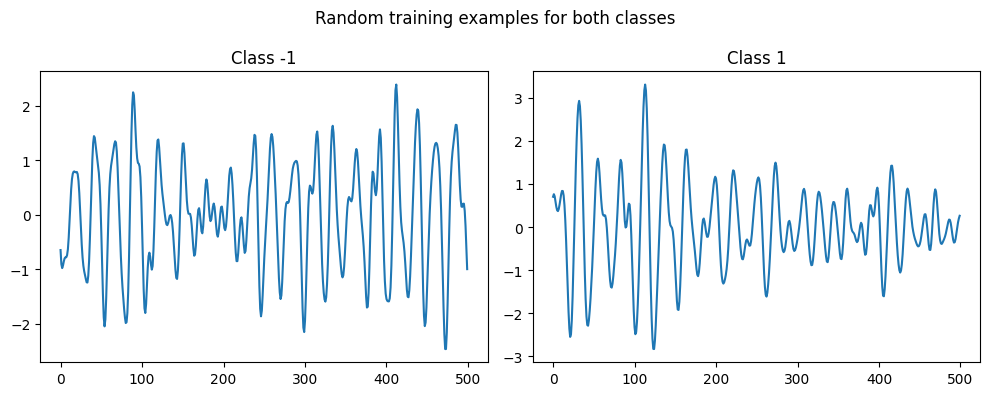

In [8]:
# Pick one random sample per class
idx_neg = np.random.choice(np.where(y_train == -1)[0])
idx_pos = np.random.choice(np.where(y_train == 1)[0])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(X_train[idx_neg])
plt.title("Class -1")

plt.subplot(1, 2, 2)
plt.plot(X_train[idx_pos])
plt.title("Class 1")

plt.suptitle("Random training examples for both classes")
plt.tight_layout()
plt.show()

## Initialize PyTorch Datasets and Dataloaders

In [9]:
# TODO: Add comments to the FordA dataset definition. Which transformations are applied to the data?

class FordADataset(Dataset):
    def __init__(self, X, y):
        X = torch.tensor(X, dtype=torch.float32)

        mean = X.mean(dim=1, keepdim=True)
        std = X.std(dim=1, keepdim=True)
        X = (X - mean) / (std + 1e-8)

        X = X.unsqueeze(-1)

        y = ((torch.tensor(y) + 1) // 2).long()

        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
train_ds = FordADataset(X_train, y_train)
test_ds = FordADataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

## Define the LSTM classifier

In [11]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        """
        Args
            input_size: number of features per timestep
            hidden_size: hidden dimensionality of the LSTM
            num_classes: Number of classes in the dataset
        """
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.norm = nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, time, features)
        out, _ = self.lstm(x)  # Apply LSTM, out: (batch, time, hidden)
        pooled = out.mean(dim=1)  # Average over the timesteps
        pooled = self.norm(pooled)  # Apply layer norm to stabilize training 
        pooled = self.dropout(pooled)  # Apply dropout for regularization
        logits = self.fc(pooled)  # Final linear layer, outputs one score for each class
        return logits

In [12]:
# TODO: Initialize the model. Use a hidden dimensionality of 64 for the LSTM.

In [13]:
model = LSTMClassifier(input_size=1, hidden_size=64, num_classes=2)

## Train the model

In [14]:
# TODO: Add comments to the training function. In particular, mark the steps that are listed in the pseudo code in the lecture slides.

def train(model, train_loader, num_epochs, device='cpu'):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    for epoch in range(num_epochs):
        total_loss = 0.0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(X)

            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")

    return model

In [15]:
# TODO: Train the model for 50 epochs. For faster training, you may use a GPU, if available. In case of memory errors, try reducing the batch size or hidden dimensionality.

In [16]:
device = 'mps'
num_epochs = 50
model = train(model=model, train_loader=train_loader, num_epochs=num_epochs, device=device)

Epoch 1/50 | Loss: 0.7198
Epoch 2/50 | Loss: 0.6984
Epoch 3/50 | Loss: 0.6954
Epoch 4/50 | Loss: 0.6962
Epoch 5/50 | Loss: 0.6966
Epoch 6/50 | Loss: 0.6934
Epoch 7/50 | Loss: 0.6969
Epoch 8/50 | Loss: 0.6957
Epoch 9/50 | Loss: 0.6949
Epoch 10/50 | Loss: 0.6967
Epoch 11/50 | Loss: 0.6961
Epoch 12/50 | Loss: 0.6956
Epoch 13/50 | Loss: 0.6970
Epoch 14/50 | Loss: 0.6936
Epoch 15/50 | Loss: 0.6943
Epoch 16/50 | Loss: 0.6940
Epoch 17/50 | Loss: 0.6937
Epoch 18/50 | Loss: 0.6945
Epoch 19/50 | Loss: 0.6950
Epoch 20/50 | Loss: 0.6941
Epoch 21/50 | Loss: 0.6938
Epoch 22/50 | Loss: 0.6972
Epoch 23/50 | Loss: 0.6957
Epoch 24/50 | Loss: 0.6927
Epoch 25/50 | Loss: 0.6932
Epoch 26/50 | Loss: 0.6939
Epoch 27/50 | Loss: 0.6930
Epoch 28/50 | Loss: 0.6927
Epoch 29/50 | Loss: 0.6932
Epoch 30/50 | Loss: 0.6917
Epoch 31/50 | Loss: 0.6936
Epoch 32/50 | Loss: 0.6927
Epoch 33/50 | Loss: 0.6936
Epoch 34/50 | Loss: 0.6914
Epoch 35/50 | Loss: 0.6921
Epoch 36/50 | Loss: 0.6862
Epoch 37/50 | Loss: 0.6268
Epoch 38/5

## Evaluate the model

In [17]:
# TODO: Evaluate the trained model on the train and test sets in terms of accuracy.

In [18]:
def evaluate(model, loader, device):
    model.to(device)
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [19]:
train_accuracy = evaluate(model=model, loader=train_loader, device=device)
print('Train accuracy:', train_accuracy)

Train accuracy: 0.9000277700638711


In [20]:
test_accuracy = evaluate(model=model, loader=test_loader, device=device)
print('Train accuracy:', test_accuracy)

Train accuracy: 0.8931818181818182
